# Phase 4 — A Benchtop Sandbox for Experimental Design

The mechanistic models of the earlier phases (chromatography, UF/DF, fermentation)
are faithful but mathematically heavy. This notebook uses four **benchtop** systems
from `downstream_doe.models.benchtop`, each governed by one or two equations, as a
sandbox to *practise* the DoE methods where the mechanism never gets in the way of
the lesson.

| System | Response shape | Method practised |
|---|---|---|
| Pipe pressure drop | product of powers | factorial on **log** factors |
| Falling-ball viscometer | inferred, not measured | **parameter estimation** / calibration |
| Yogurt back-extrusion | curved + threshold | **LHS + RSM + GLM** design space |
| Methyl-acetate hydrolysis | kinetics → shifting equilibrium | design with **time** as a factor |

This mirrors Chapter 4 of the monograph; every number is real model output.

In [1]:
# %matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from downstream_doe.config import make_rng
from downstream_doe import perturbation as pert
from downstream_doe.doe.factorial import Factor, full_factorial, run_design
from downstream_doe.doe.analysis import fit_response_model, fit_glm_response, predict_glm_grid
from downstream_doe.doe.lhs import latin_hypercube, coverage_metrics
from downstream_doe.models.benchtop import pipe_flow as pf, falling_ball as fb
from downstream_doe.models.benchtop import back_extrusion as be, ester_hydrolysis as eh

rng = make_rng(4)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

## 4.1  Pipe pressure drop — a factorial in the logarithms

Hagen–Poiseuille, $\Delta P = 128\mu L Q/(\pi d^4)$, is a **product of powers**, so
on a log scale it is *linear*: the mechanistic exponents $(+1, +1, -4)$ become the
main-effect slopes. A $2^3$ factorial in $(\log Q, \log L, \log d)$ should recover
them exactly — and reveal that a raw-scale analysis would need large interactions.

In [2]:
factors = [Factor('logQ', np.log(1e-6), np.log(4e-6)),
           Factor('logL', np.log(0.5),  np.log(2.0)),
           Factor('logd', np.log(3e-3), np.log(5e-3))]
design = full_factorial(factors, levels=2, center_points=3)

def eval_pipe(pt):
    cfg = pf.PipeFlowConfig(flow_rate=np.exp(pt['logQ']), length=np.exp(pt['logL']),
                            diameter=np.exp(pt['logd']), temperature=20.0)
    return {'logdP': np.log(pf.pressure_drop(cfg))}

data = run_design(design, eval_pipe)
fit = fit_response_model(data, 'logdP', ['logQ','logL','logd'], interactions=False)
print('fitted log-log slopes  (mechanistic truth in parentheses)')
for name, truth in [('logQ', +1), ('logL', +1), ('logd', -4)]:
    print(f'  {name}: {fit.effects[name]:+.3f}   ({truth:+d})')
print(f'R^2 = {fit.model.rsquared:.6f}')

fitted log-log slopes  (mechanistic truth in parentheses)
  logQ: +1.000   (+1)
  logL: +1.000   (+1)
  logd: -4.000   (-4)
R^2 = 1.000000


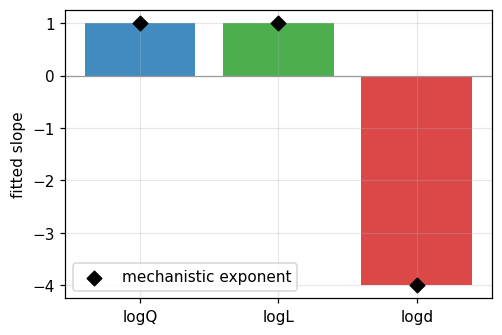

In [3]:
fig, ax = plt.subplots(figsize=(5,3.4))
names, vals, truth = ['logQ','logL','logd'], [fit.effects[n] for n in ['logQ','logL','logd']], [1,1,-4]
ax.bar(names, vals, color=['#1f77b4','#2ca02c','#d62728'], alpha=.85)
ax.scatter(names, truth, color='k', marker='D', zorder=5, s=45, label='mechanistic exponent')
ax.axhline(0, color='.6', lw=.8); ax.set_ylabel('fitted slope'); ax.legend(); plt.show()

## 4.2  Falling-ball viscometer — calibration and the operating point

The target (viscosity $\mu$) is **inferred** from a measured fall time, not read
directly. The classic Stokes inversion is biased whenever the ball leaves creeping
flow — and the bias is a function of the *operating point* $(d, \rho_s)$. A good
calibration design keeps $\mathrm{Re}\ll 1$; the full inversion (`stokes_only=False`)
recovers $\mu$ from every corner.

In [4]:
MU_TRUE = 0.8
ball_factors = [Factor('d', 1.0e-3, 3.0e-3), Factor('rho_s', 7000., 8000.)]
bdesign = full_factorial(ball_factors, levels=2)

def eval_ball(pt):
    cfg = fb.FallingBallConfig(ball_diameter=pt['d'], ball_density=pt['rho_s'],
                               fluid_density=1260., fluid_viscosity=MU_TRUE,
                               tube_diameter=0.03, fall_distance=0.1)
    t = fb.fall_time(cfg)
    return {'Re': fb.reynolds_number(cfg), 'fall_time_s': t,
            'mu_stokes': fb.infer_viscosity(t, cfg, stokes_only=True),
            'mu_full':   fb.infer_viscosity(t, cfg, stokes_only=False)}

bdata = run_design(bdesign, eval_ball).round(4)
print(bdata[['d','rho_s','Re','fall_time_s','mu_stokes','mu_full']].to_string(index=False))
print(f'\ntrue mu = {MU_TRUE}: full inversion recovers it everywhere; '
      'the Stokes reading is biased high, worst at the largest Re.')

    d  rho_s     Re  fall_time_s  mu_stokes  mu_full
0.001 8000.0 0.0067      23.5459     0.8040      0.8
0.003 8000.0 0.1476       3.2023     0.8378      0.8
0.001 7000.0 0.0057      27.6335     0.8036      0.8
0.003 7000.0 0.1262       3.7429     0.8340      0.8

true mu = 0.8: full inversion recovers it everywhere; the Stokes reading is biased high, worst at the largest Re.


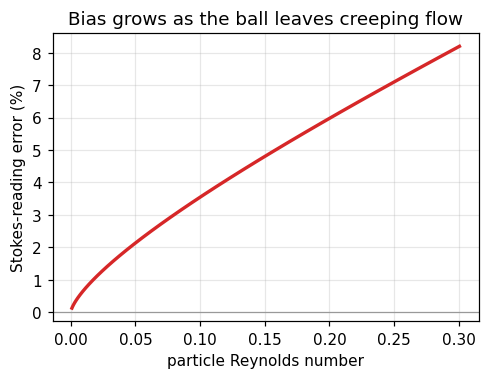

In [5]:
# The bias as a smooth function of Reynolds number
diams = np.linspace(0.5e-3, 4e-3, 40)
def cfg(d): return fb.FallingBallConfig(ball_diameter=d, ball_density=7800., fluid_density=1260.,
                                        fluid_viscosity=MU_TRUE, tube_diameter=0.03, fall_distance=0.1)
Re  = np.array([fb.reynolds_number(cfg(d)) for d in diams])
err = np.array([100*(fb.infer_viscosity(fb.fall_time(cfg(d)), cfg(d), stokes_only=True)-MU_TRUE)/MU_TRUE
                for d in diams])
fig, ax = plt.subplots(figsize=(5,3.4))
ax.plot(Re, err, color='#d62728', lw=2.2); ax.axhline(0, color='.6', lw=.8)
ax.set_xlabel('particle Reynolds number'); ax.set_ylabel('Stokes-reading error (%)')
ax.set_title('Bias grows as the ball leaves creeping flow'); plt.show()

## 4.3  Yogurt back-extrusion — LHS, a response surface, and a pass/fail spec

The peak probe force is **curved** in the operating factors (speed enters through a
power $n<1$, temperature through an Arrhenius factor) and the industrial question is
a **pass/fail** texture spec. We space-fill the operating box with a Latin hypercube,
fit a quadratic response surface, then a logistic GLM for the *probabilistic design
space* — exactly as for the purity/breakthrough specs of Chapter 2.

In [6]:
HB = be.HerschelBulkley(consistency=20.0, flow_index=0.4, yield_stress=35.0)
yog_factors = [Factor('speed', 3e-4, 4e-3), Factor('temperature', 5.0, 25.0)]
lhs = latin_hypercube(yog_factors, n_samples=40, seed=4)
print('LHS coverage:', {k: round(v,3) for k,v in coverage_metrics(lhs).items()})

def eval_yog(pt):
    cfg = be.BackExtrusionConfig(rheology=HB, probe_speed=pt['speed'],
                                 temperature=pt['temperature'], density=1040.)
    return {'force': be.peak_force(cfg)}

ydata = run_design(lhs, eval_yog)
rsm = fit_response_model(ydata, 'force', ['speed','temperature'],
                         interactions=True, quadratic=True)
print(f'\nquadratic RSM  R^2 = {rsm.model.rsquared:.4f}')

LHS coverage: {'discrepancy': 0.001, 'min_pairwise_dist': 0.063, 'mean_pairwise_dist': 0.55}

quadratic RSM  R^2 = 0.9984


firmness spec = 0.26 N   |   GLM pseudo-R^2 = 1.000


/home/ali/projects/DOE/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/ali/projects/DOE/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/ali/projects/DOE/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


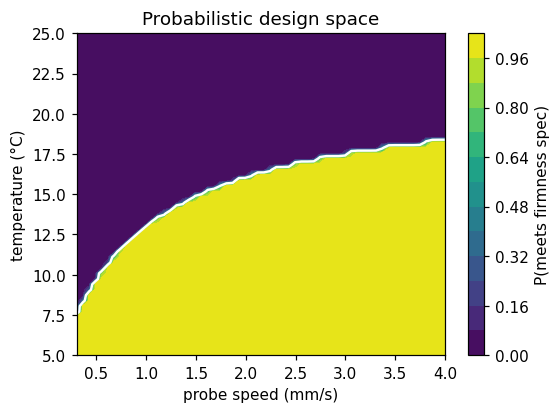

In [7]:
# Probabilistic design space: P(force >= firmness spec) via logistic GLM
SPEC = float(np.median(ydata['force']))          # firmness threshold (balanced classes)
ydata['pass'] = (ydata['force'] >= SPEC).astype(int)
glm = fit_glm_response(ydata, 'pass', ['speed','temperature'],
                       family='binomial', interactions=True)
print(f'firmness spec = {SPEC:.2f} N   |   GLM pseudo-R^2 = {glm.pseudo_r2:.3f}')

X, Y, P = predict_glm_grid(glm, 'speed', 'temperature', (3e-4,4e-3), (5.,25.))
fig, ax = plt.subplots(figsize=(5.4,3.8))
cf = ax.contourf(X*1e3, Y, P, levels=12, cmap='viridis')
ax.contour(X*1e3, Y, P, levels=[0.5], colors='w', linewidths=1.6)
fig.colorbar(cf, ax=ax, label='P(meets firmness spec)')
ax.set_xlabel('probe speed (mm/s)'); ax.set_ylabel('temperature (°C)')
ax.set_title('Probabilistic design space'); ax.grid(False); plt.show()

## 4.4  Methyl-acetate hydrolysis — putting *time* in the design

A slow reversible reaction: acid **speeds the approach to equilibrium but does not
move it**, while temperature moves both rate and (via van 't Hoff) equilibrium. A
factorial in $(T, c_{H^+}, t)$ with noisy conversion readings gives an ANOVA with a
strong catalyst×time interaction — the signature of a kinetic response that demands
*time* be a designed factor. (Temperature capped below the 56.9 °C boiling point.)

In [8]:
ester_factors = [Factor('temperature', 25., 50.),
                 Factor('catalyst', 0.05, 0.4),
                 Factor('time_h', 0.5, 4.0)]
edesign = full_factorial(ester_factors, levels=3, center_points=3)

def eval_ester(pt):
    cfg = eh.EsterHydrolysisConfig(temperature=pt['temperature'], catalyst_conc=pt['catalyst'])
    x = eh.conversion_at(cfg, pt['time_h']*3600.0)
    return {'conversion': x}

edata = run_design(edesign, eval_ester)
# layer realistic measurement noise -> a genuine 'virtual experiment'
edata['conversion'] = pert.add_measurement_noise(
    edata['time_h'].to_numpy(), edata['conversion'].to_numpy(),
    pert.NoiseModel(additive_sd=0.004, proportional_cv=0.02), rng)

fit_e = fit_response_model(edata, 'conversion', ['temperature','catalyst','time_h'],
                           interactions=True, quadratic=True)
tbl = fit_e.anova_table.sort_values('sum_sq', ascending=False)
print(tbl[['sum_sq','F','PR(>F)']].head(8).round(5).to_string())

                       sum_sq         F   PR(>F)
time_h                0.03024  39.78116  0.00000
catalyst              0.02691  35.40160  0.00001
Residual              0.01520       NaN      NaN
I(time_h ** 2)        0.01335  17.56430  0.00045
I(catalyst ** 2)      0.01141  15.00603  0.00094
catalyst:time_h       0.00909  11.95278  0.00249
temperature:catalyst  0.00443   5.83260  0.02543
temperature:time_h    0.00399   5.25292  0.03289


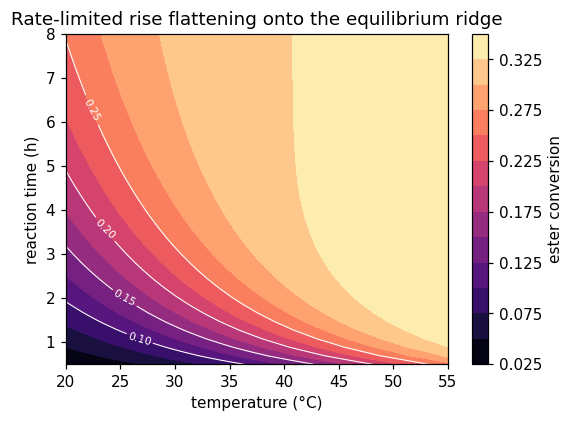

In [9]:
# The (T, time) conversion surface at fixed acid — two regimes in one picture
temps = np.linspace(20, 55, 40); hours = np.linspace(0.5, 8, 40)
T, H = np.meshgrid(temps, hours)
Z = np.array([[eh.conversion_at(eh.EsterHydrolysisConfig(temperature=float(t), catalyst_conc=0.1),
               float(h)*3600.) for t in temps] for h in hours])
fig, ax = plt.subplots(figsize=(5.6,3.9))
cf = ax.contourf(T, H, Z, levels=14, cmap='magma')
cs = ax.contour(T, H, Z, levels=[.1,.15,.2,.25], colors='w', linewidths=.7); ax.clabel(cs, fontsize=7, fmt='%.2f')
fig.colorbar(cf, ax=ax, label='ester conversion')
ax.set_xlabel('temperature (°C)'); ax.set_ylabel('reaction time (h)')
ax.set_title('Rate-limited rise flattening onto the equilibrium ridge'); ax.grid(False); plt.show()

## Takeaway

Read the **shape** of the response and let it choose the design:

* **power law** → factorial on the log scale (pipe);
* **inferred target** → parameter estimation, and design the operating point to control bias (falling ball);
* **curvature + threshold** → LHS/RSM plus a GLM design space (yogurt);
* **kinetics toward a shifting equilibrium** → put *time* in the design and separate rate from equilibrium (ester).

The intuition earned on these transparent systems transfers straight back to the
harder chromatography and fermentation problems of the earlier phases.